<a href="https://colab.research.google.com/github/Rafna123/Regression-Analysis-of-Academic-Performance/blob/main/Regression_Analysis_of_Academic_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
This project builds a regression model to predict students’ exam scores based on factors such as study hours,
#attendance, previous grades, socioeconomic indicators, and extracurricular involvement.
#Using datasets like student performance from schools or online repositories,
# the model learns patterns and relationships to estimate a student’s expected score.
#Performance is evaluated using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE),
#and R² score, providing insights into the key factors influencing academic outcomes.

In [ ]:
#import all libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Student_Performance.csv")
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [ ]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Extracurricular Activities"]=le.fit_transform(df["Extracurricular Activities"])
df["Extracurricular Activities"]

,Extracurricular Activities
0,1
1,0
2,1
3,1
4,0
...,...
9995,1
9996,1
9997,1
9998,1


In [ ]:
df["Performance Index"]=le.fit_transform(df["Performance Index"])
df["Performance Index"]

,Performance Index
0,81
1,55
2,35
3,26
4,56
...,...
9995,13
9996,48
9997,64
9998,85


In [ ]:
features=list(zip(df["Extracurricular Activities"],df["Performance Index"]))
features

[(1, 81),
 (0, 55),
 (1, 35),
 (1, 26),
 (0, 56),
 (0, 51),
 (1, 53),
 (1, 32),
 (0, 51),
 (0, 59),
 (0, 74),
 (0, 63),
 (0, 17),
 (0, 23),
 (0, 58),
 (0, 33),
 (1, 57),
 (1, 60),
 (1, 20),
 (0, 53),
 (1, 61),
 (0, 75),
 (1, 63),
 (0, 47),
 (0, 25),
 (1, 39),
 (0, 56),
 (1, 73),
 (1, 64),
 (1, 64),
 (1, 29),
 (1, 26),
 (1, 48),
 (1, 37),
 (1, 50),
 (1, 64),
 (0, 32),
 (0, 58),
 (1, 22),
 (0, 54),
 (0, 35),
 (1, 29),
 (1, 48),
 (0, 26),
 (1, 61),
 (1, 44),
 (1, 7),
 (0, 44),
 (1, 48),
 (0, 43),
 (1, 17),
 (1, 55),
 (0, 65),
 (1, 42),
 (0, 68),
 (0, 81),
 (1, 23),
 (1, 37),
 (0, 68),
 (0, 28),
 (1, 60),
 (1, 88),
 (1, 77),
 (1, 39),
 (1, 31),
 (0, 61),
 (0, 44),
 (0, 32),
 (0, 81),
 (1, 51),
 (0, 64),
 (1, 44),
 (1, 71),
 (1, 42),
 (1, 55),
 (1, 26),
 (0, 51),
 (1, 25),
 (1, 5),
 (1, 78),
 (0, 35),
 (1, 39),
 (1, 23),
 (1, 50),
 (0, 61),
 (1, 71),
 (0, 57),
 (0, 85),
 (1, 48),
 (0, 19),
 (0, 11),
 (1, 28),
 (1, 50),
 (1, 66),
 (1, 59),
 (0, 20),
 (0, 47),
 (1, 71),
 (1, 26),
 (1, 15),
 (

In [ ]:
#feature matrix
x=df.iloc[:,:-1].values
x

array([[ 7, 99,  1,  9,  1],
       [ 4, 82,  0,  4,  2],
       [ 8, 51,  1,  7,  2],
       ...,
       [ 6, 83,  1,  8,  5],
       [ 9, 97,  1,  7,  0],
       [ 7, 74,  0,  8,  1]])

In [ ]:
#target matrix
y=df.iloc[:,-1].values
y

array([81, 55, 35, ..., 64, 85, 54])

In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


<Axes: xlabel='Hours Studied'>

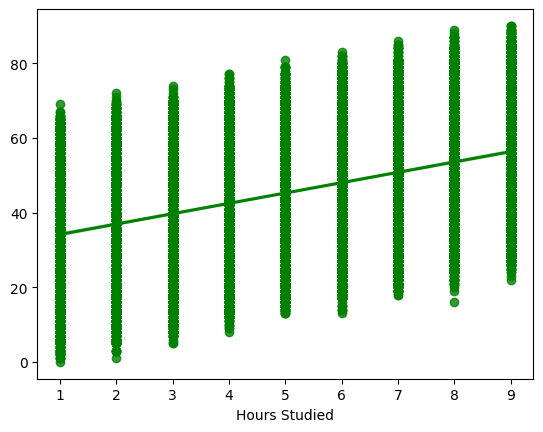

In [ ]:
#create a scatter plot with a linear regression line using the seaborn library.
sns.regplot(x=df["Hours Studied"],y=y,color="green")

<Axes: xlabel='Previous Scores'>

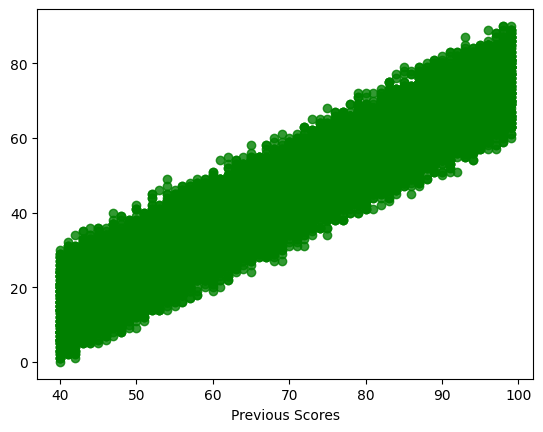

In [ ]:
sns.regplot(x=df["Previous Scores"],y=y,color="green")

<Axes: xlabel='Extracurricular Activities'>

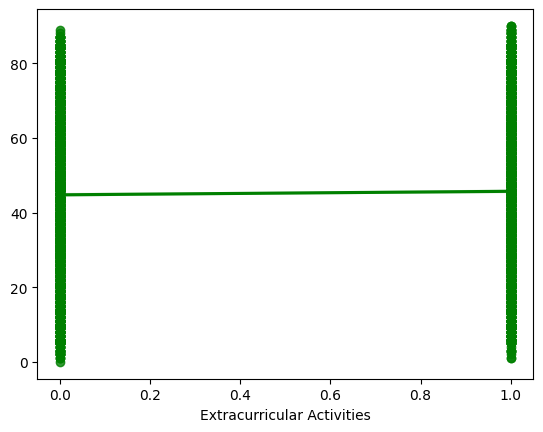

In [ ]:
sns.regplot(x=df["Extracurricular Activities"],y=y,color="green")

<Axes: xlabel='Sleep Hours'>

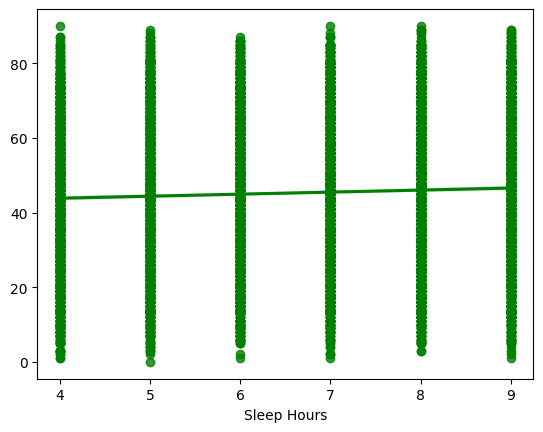

In [ ]:
sns.regplot(x=df["Sleep Hours"],y=y,color="green")

<Axes: xlabel='Sample Question Papers Practiced'>

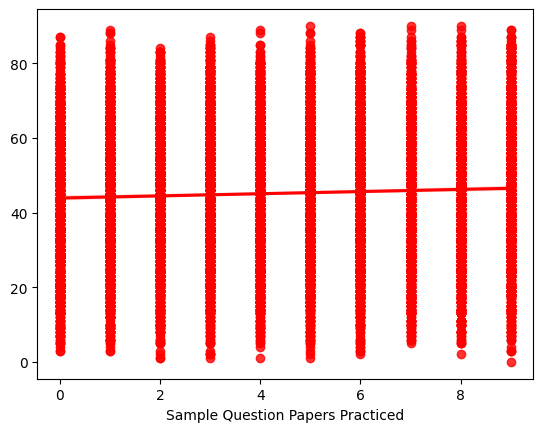

In [ ]:
sns.regplot(x=df["Sample Question Papers Practiced"],y=y,color="red")

<Axes: xlabel='Performance Index'>

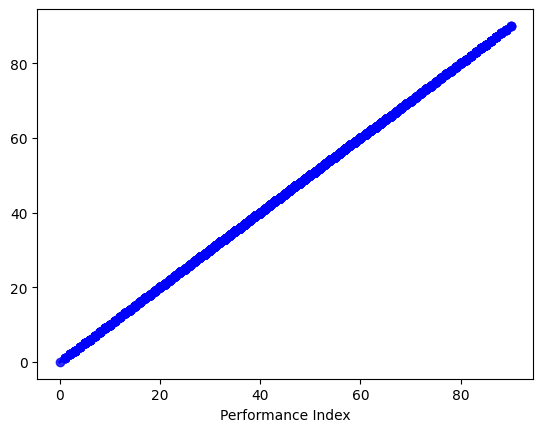

In [ ]:
sns.regplot(x=df["Performance Index"],y=y,color="blue")

In [ ]:
# 70% of data were train and 30% data where test the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

array([[ 4, 85,  0,  7,  5],
       [ 2, 77,  0,  9,  1],
       [ 3, 45,  0,  9,  9],
       ...,
       [ 8, 93,  0,  9,  0],
       [ 3, 98,  0,  7,  2],
       [ 3, 54,  1,  6,  3]])

In [ ]:
x_train

array([[ 4, 85,  0,  7,  5],
       [ 2, 77,  0,  9,  1],
       [ 3, 45,  0,  9,  9],
       ...,
       [ 8, 93,  0,  9,  0],
       [ 3, 98,  0,  7,  2],
       [ 3, 54,  1,  6,  3]])

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([51.17057416, 53.78913778, 67.73596894, ..., 75.7751157 ,
       52.93382941, 33.72125123])

In [ ]:
print(model.predict([[13,34,5,12,5]]))

[37.37151853]


In [ ]:
#creates a new pandas DataFrame named df1 to compare the actual target values
#from your test set (y_test)
#with the predicted target values generated by your model (y_pred).
df1=pd.DataFrame({"actual value":y_test,"predicted value":y_pred})
df1

,actual value,predicted value
0,48,51.170574
1,54,53.789138
2,65,67.735969
3,49,53.447275
4,76,76.387768
...,...,...
2995,41,35.081534
2996,22,21.726320
2997,77,75.775116
2998,58,52.933829


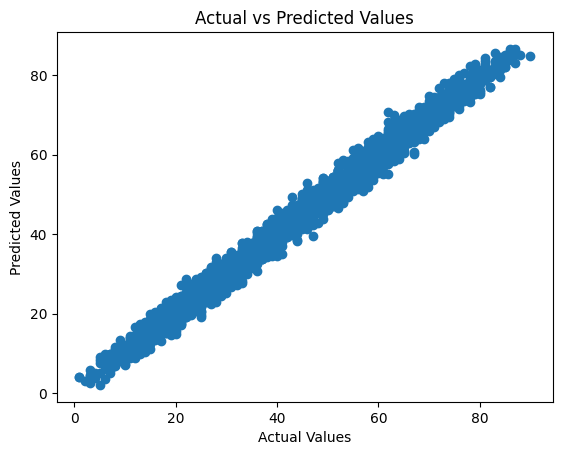

In [ ]:
plt.scatter(y_test,y_pred )
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [ ]:
#calculate the Mean Absolute Error between ypur actual value and predicted value.
print("mean absolute error",mean_absolute_error(y_test,y_pred))

mean absolute error 1.6173174221523676


In [ ]:
#calculate the Mean Absolute Percentage Error between actual value and predicted value.
print("mean absolute percentage error",mean_absolute_percentage_error(y_test,y_pred))

mean absolute percentage error 0.049797371398824945


In [ ]:
#calculate the Mean Squared Error between actual value and predicted value.
print("mean squared error",mean_squared_error(y_test,y_pred))

mean squared error 4.212998016862821


In [ ]:
#calculate the Root Mean Squared Error between actual value and predicted value.
from sklearn.metrics import root_mean_squared_error
x=mean_squared_error(y_test,y_pred)
print("root mean squared error",np.sqrt(x))

root mean squared error 2.0525588948585183


In [ ]:
# to display the coefficients of the trained linear regression model.
print("slope is",model.coef_)

slope is [2.85406022 1.01826685 0.59659517 0.47551045 0.19146725]
